In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/SupplyChain_DeliveryRiskPrediction_20260314.csv", encoding="latin1")
print(df.shape)
df.head()

(180031, 38)


,Order Id,Product Name,Category Name,Department Name,Order Region,Order Country,Order City,Customer Segment,Late_delivery_risk,Shipping Mode,...,ShippingMode_Late_Delivery_Rate,ShippingMode_Avg_Scheduled_Days,Segment_Late_Delivery_Rate,Latitude,Longitude,Market,order date (DateOrders),Delivery Status,Benefit per order,Order Item Profit Ratio
0,77202,Smart watch,Sporting Goods,Fitness,Southeast Asia,Indonesia,Bekasi,Consumer,0,Standard Class,...,0.380717,4.0,0.548084,18.251453,-66.037056,Pacific Asia,1/31/2018 22:56,Advance shipping,91.250000,0.29
1,75939,Smart watch,Sporting Goods,Fitness,South Asia,India,Bikaner,Consumer,1,Standard Class,...,0.380717,4.0,0.548084,18.279451,-66.037064,Pacific Asia,1/13/2018 12:27,Late delivery,-249.089996,-0.80
2,75938,Smart watch,Sporting Goods,Fitness,South Asia,India,Bikaner,Consumer,0,Standard Class,...,0.380717,4.0,0.548084,37.292233,-121.881279,Pacific Asia,1/13/2018 12:06,Shipping on time,-247.779999,-0.80
3,75937,Smart watch,Sporting Goods,Fitness,Oceania,Australia,Townsville,Home Office,0,Standard Class,...,0.380717,4.0,0.550704,34.125946,-118.291016,Pacific Asia,1/13/2018 11:45,Advance shipping,22.860001,0.08
4,75936,Smart watch,Sporting Goods,Fitness,Oceania,Australia,Townsville,Corporate,0,Standard Class,...,0.380717,4.0,0.547227,18.253769,-66.037048,Pacific Asia,1/13/2018 11:24,Advance shipping,134.210007,0.45


In [3]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])

In [4]:
df["month"] = df["order date (DateOrders)"].dt.month
df["day_of_week"] = df["order date (DateOrders)"].dt.dayofweek
df["quantity_price_interaction"] = df["Order Item Quantity"] * df["Product Price"]
df["logistics_pressure"] = (df["Order Item Quantity"] *df["Days for shipment (scheduled)"])
df["region_order_density"] = df.groupby("Order Region")["Order Item Quantity"].transform("mean")

In [5]:
features = [
"Order Item Quantity",
"Sales",
"Product Price",
"Shipping Mode",
"Order Region",
"Order Country",
"Customer Segment",
"Days for shipment (scheduled)",
"Demand_Spike_Flag",
"High_Demand_Risk_Flag",
"Logistics_Load_Score",
"logistics_pressure",
"region_order_density",
"month",
"day_of_week"
]

target = "Late_delivery_risk"

In [6]:
X = df[features]
y = df[target]

In [7]:
X = pd.get_dummies(X, drop_first=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

In [10]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,
    gamma=0.1,
    reg_lambda=2,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [11]:
pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]



In [12]:
print(classification_report(y_test, pred))



              precision    recall  f1-score   support

           0       0.63      0.87      0.73     16261
           1       0.84      0.58      0.69     19746

    accuracy                           0.71     36007
   macro avg       0.74      0.72      0.71     36007
weighted avg       0.75      0.71      0.71     36007



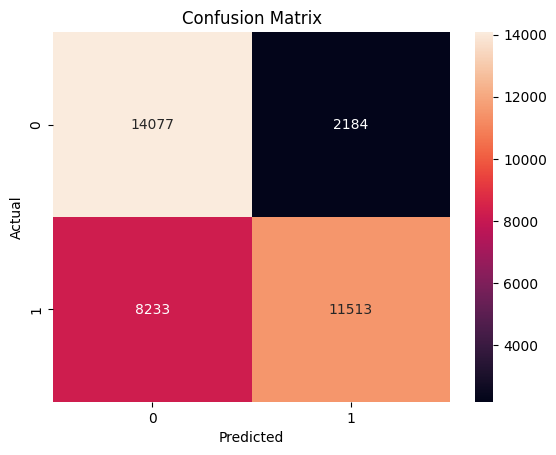

In [13]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
print("ROC AUC:", roc_auc_score(y_test, prob))

ROC AUC: 0.7707839098398253


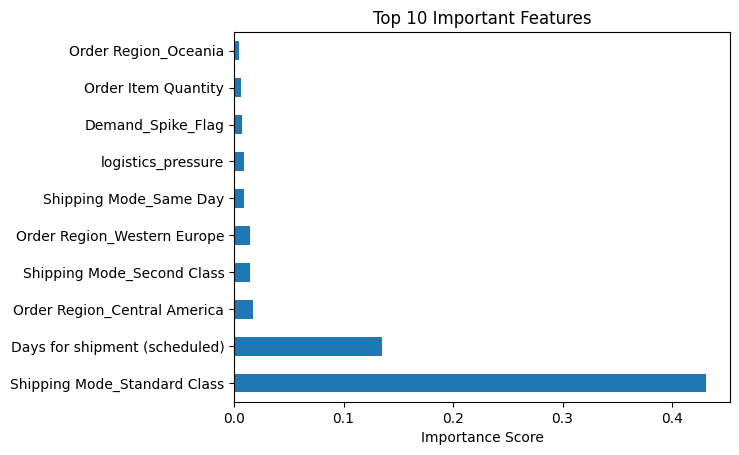

In [15]:
importance = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)

feat_imp.nlargest(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

In [16]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)
probability = model.predict_proba(sample)

print("Late delivery prediction:", prediction)
print("Delay probability:", probability[:,1])

Late delivery prediction: [0]
Delay probability: [0.3703452]


In [17]:
import joblib

joblib.dump(model, "../models/late_delivery_model.pkl")
joblib.dump(X.columns, "../models/model_features.pkl")

print("Model saved successfully")

Model saved successfully
